In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Model
from sklearn.linear_model import LinearRegression

# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
## 2. Load Dataset

In [5]:
df = pd.read_csv("manufacturing_dataset_1000_samples.csv")

# Show data
print(df.head())
print(df.info())

          Timestamp  Injection_Temperature  Injection_Pressure  Cycle_Time  \
0  01-01-2023 00:00                  221.0               136.0        28.7   
1  01-01-2023 01:00                  213.3               128.9        34.5   
2  01-01-2023 02:00                  222.8               115.9        19.9   
3  01-01-2023 03:00                  233.3               105.3        39.2   
4  01-01-2023 04:00                  212.2               125.5        45.0   

   Cooling_Time  Material_Viscosity  Ambient_Temperature  Machine_Age  \
0          13.6               375.5                 28.0          3.8   
1          14.0               215.8                 22.6          6.8   
2           9.5               307.0                 25.3          4.2   
3          13.1               137.8                 26.0          9.2   
4           9.9               298.2                 23.6          6.2   

   Operator_Experience  Maintenance_Hours    Shift Machine_Type  \
0                 11.2   

In [6]:
## 3. Data Cleaning & Preprocessing

In [7]:
#### 3.1 Drop Timestamp (if exists)

In [8]:
if 'Timestamp' in df.columns:
    df.drop('Timestamp', axis=1, inplace=True)

In [9]:
#### 3.2 Handle Missing Values

In [11]:
df.isnull().sum()

Injection_Temperature          0
Injection_Pressure             0
Cycle_Time                     0
Cooling_Time                   0
Material_Viscosity            20
Ambient_Temperature           20
Machine_Age                    0
Operator_Experience           20
Maintenance_Hours              0
Shift                          0
Machine_Type                   0
Material_Grade                 0
Day_of_Week                    0
Temperature_Pressure_Ratio     0
Total_Cycle_Time               0
Efficiency_Score               0
Machine_Utilization            0
Parts_Per_Hour                 0
dtype: int64

In [12]:
# Fill numerical columns with mean
df['Material_Viscosity'].fillna(df['Material_Viscosity'].mean(), inplace=True)
df['Ambient_Temperature'].fillna(df['Ambient_Temperature'].mean(), inplace=True)
df['Operator_Experience'].fillna(df['Operator_Experience'].mean(), inplace=True)

C:\Users\Snehal\AppData\Local\Temp\ipykernel_22796\4205979141.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Material_Viscosity'].fillna(df['Material_Viscosity'].mean(), inplace=True)
C:\Users\Snehal\AppData\Local\Temp\ipykernel_22796\4205979141.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

In [13]:
#### 3.3 Encode Categorical Variables

In [14]:
categorical_cols = ['Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [15]:
## 4. Exploratory Data Analysis (EDA)

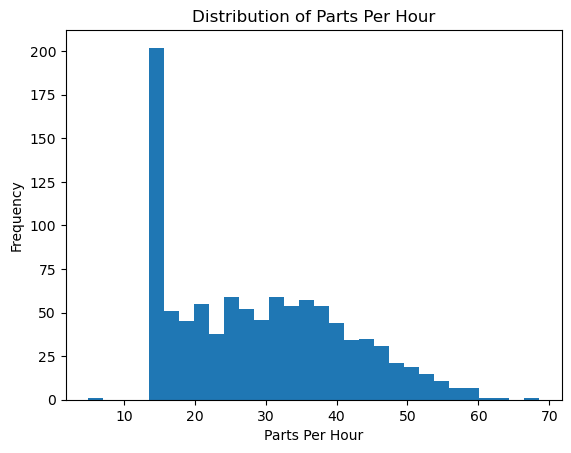

In [34]:
plt.hist(y, bins=30)
plt.title("Distribution of Parts Per Hour")
plt.xlabel("Parts Per Hour")
plt.ylabel("Frequency")
plt.show()

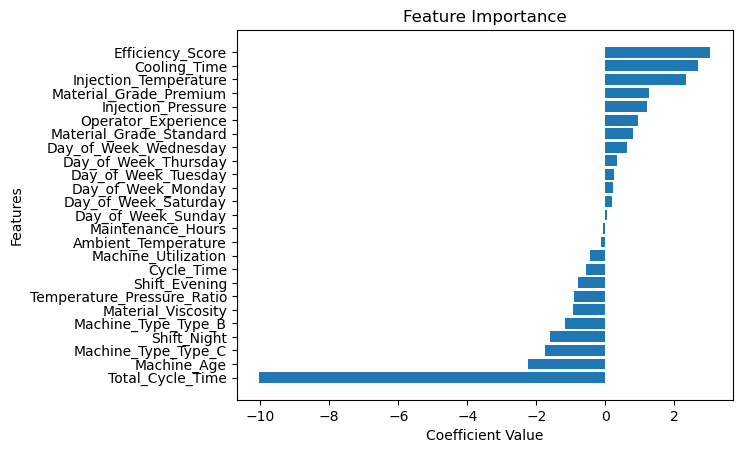

In [35]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coeff_df = coeff_df.sort_values(by="Coefficient")

plt.barh(coeff_df["Feature"], coeff_df["Coefficient"])
plt.title("Feature Importance")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()


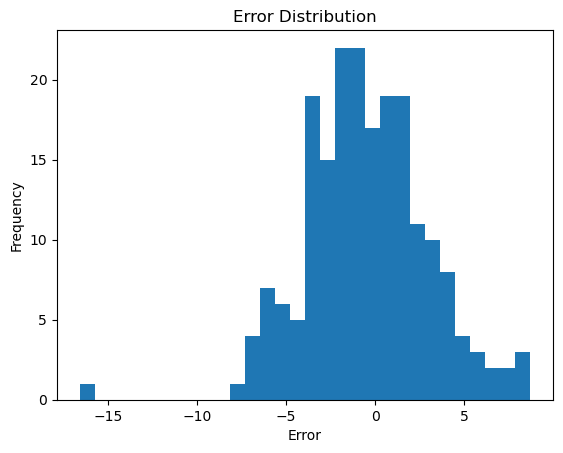

In [36]:
errors = y_test - y_pred

plt.hist(errors, bins=30)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

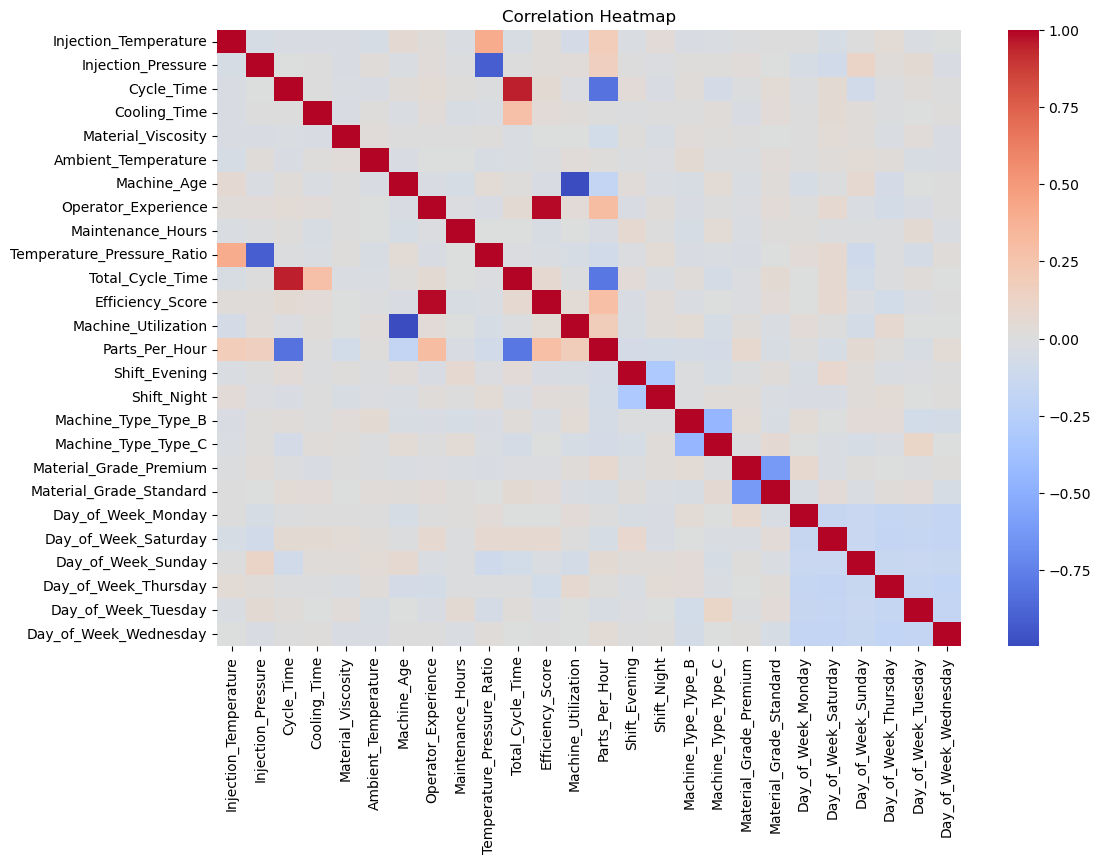

In [16]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
## 5. Define Features & Target

In [18]:
X = df.drop('Parts_Per_Hour', axis=1)
y = df['Parts_Per_Hour']

In [19]:
## 6. Feature Scaling

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
## 7. Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [24]:
## 9. Predictions

In [25]:
y_pred = model.predict(X_test)

In [26]:
## 10. Model Evaluation

In [27]:
# Regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 12.280335100794218
RMSE: 3.5043309062921297
MAE: 2.7157288381643303
R2 Score: 0.9058926590665998


In [28]:
## 13. Visualization (Actual vs Predicted)

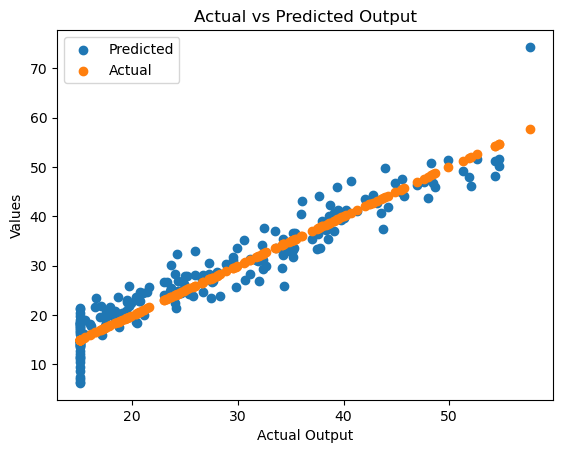

In [32]:
plt.scatter(y_test, y_pred, label="Predicted")
plt.scatter(y_test, y_test, label="Actual")

plt.xlabel("Actual Output")
plt.ylabel("Values")
plt.title("Actual vs Predicted Output")

plt.legend()
plt.show()

In [33]:
import pickle

# Save model
pickle.dump(model, open("model.pkl", "wb"))

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))